# **1. 단일 에이전트 한계**
단일 에이전트(Single Agent)는 하나의 LLM이 모든 의사결정과 작업 수행을 담당하는 구조로, 설계가 단순하고 구현 및 디버깅이 쉬우며 초기 개발 속도가 빠르다는 장점이 있습니다. 특히 LangChain 기반에서는 하나의 Agent가 Tool을 선택하고 실행하는 흐름으로 빠르게 프로토타이핑이 가능하여 교육이나 소규모 서비스에 적합합니다. 그러나 복잡한 문제에서는 계획 수립, 실행, 검증을 모두 하나의 모델이 처리해야 하므로 성능이 불안정해지고, 긴 컨텍스트에서 오류가 누적되거나 hallucination이 발생할 가능성이 높습니다. 또한 역할 분리가 되지 않아 확장성과 유지보수성이 떨어지고, 병렬 처리나 협업 구조를 만들기 어려워 대규모 시스템이나 고도화된 AI 서비스에는 한계가 존재합니다.

# **2. 멀티 에이전트**
멀티 에이전트(Multi-Agent)는 여러 개의 LLM 기반 에이전트가 각기 다른 역할을 나누어 협력하며 문제를 해결하는 구조로, 예를 들어 계획(Planner), 실행(Executor), 검증(Reviewer) 등을 분리하여 더 정교하고 안정적인 결과를 도출할 수 있는 것이 특징입니다. 각 에이전트는 자신의 전문 영역에 집중하기 때문에 복잡한 작업에서도 성능이 향상되고, 오류를 다른 에이전트가 보완하거나 검증하는 구조를 만들 수 있어 hallucination을 줄이는 데에도 효과적입니다. 또한 병렬 처리와 확장이 용이하여 실무에서 대규모 서비스나 고도화된 AI 시스템에 적합하지만, 에이전트 간 통신 설계와 상태 관리가 복잡해지고 시스템 구조가 어려워지는 단점이 있습니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2Ftbmcb%2FdJMcadVKM6j%2FAAAAAAAAAAAAAAAAAAAAAA7C2PqT2NhfW1Yx5qNBn0kKoUvWxmvdRkglH8JvRfVv%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1777561199%26allow_ip%3D%26allow_referer%3D%26signature%3DNQsEs4eRHIAfkF6lplFSEJwxH1A%253D'>

### 1️⃣ Single (단일 에이전트 구조)
Single 구조는 하나의 에이전트가 모든 작업(이해, 판단, 실행)을 수행하는 가장 기본적인 형태로, 설계가 단순하고 구현 및 디버깅이 쉬워 초기 학습이나 프로토타입 개발에 적합합니다. LangChain에서는 하나의 Agent가 여러 Tool을 호출하는 방식으로 구현되며 빠르게 결과를 만들 수 있다는 장점이 있습니다. 그러나 복잡한 문제에서는 역할 분리가 되지 않아 성능이 불안정해지고, 긴 추론 과정에서 오류가 누적되거나 hallucination이 발생할 가능성이 높으며, 확장성과 유지보수성이 떨어지는 한계가 있습니다.

### 2️⃣ Network (네트워크형 구조)
Network 구조는 여러 에이전트가 서로 동등한 관계에서 직접 통신하며 협업하는 분산형 구조로, 특정 중앙 제어자 없이 각 에이전트가 자율적으로 판단하고 메시지를 주고받으며 문제를 해결합니다. 이 구조는 다양한 관점에서 문제를 탐색하거나 브레인스토밍, 집단 지능이 필요한 상황에서 강점을 가지며 확장성과 유연성이 뛰어납니다. 하지만 에이전트 간 상호작용이 복잡해지면서 상태 관리와 흐름 제어가 어려워지고, 예측 가능한 결과를 보장하기 어렵다는 단점이 있습니다.

### 3️⃣ Supervisor (관리자 중심 구조)
Supervisor 구조는 하나의 상위 에이전트가 전체 작업을 계획하고, 여러 하위 에이전트에게 작업을 분배 및 관리하는 중앙집중형 구조입니다. Supervisor는 어떤 에이전트를 언제 호출할지 결정하며 전체 흐름을 통제하기 때문에 안정적인 실행과 디버깅이 용이합니다. 이 구조는 실무에서 가장 많이 사용되는 패턴 중 하나로, 복잡한 작업을 체계적으로 관리할 수 있다는 장점이 있지만, 중앙 에이전트에 의존하기 때문에 병목이 발생할 수 있고 확장성에 제약이 있을 수 있습니다.

### 4️⃣ Supervisor (as Tools) 구조
Supervisor(as Tools) 구조는 하위 에이전트들을 각각 하나의 “Tool”처럼 등록하여, Supervisor 에이전트가 Tool 호출 방식으로 다른 에이전트를 사용하는 구조입니다. 즉, 에이전트 간 관계를 명시적인 메시지 전달이 아니라 Tool 호출 인터페이스로 단순화한 형태입니다. 이 방식은 LangChain/LangGraph에서 구현이 매우 직관적이고, 기존 Tool 기반 Agent 패턴을 그대로 확장할 수 있어 실무 적용이 쉽다는 장점이 있습니다. 다만 하위 에이전트의 자율성이 제한되고, 복잡한 협업이나 상호 토론 구조를 만들기에는 한계가 있습니다.

### 5️⃣ Hierarchical (계층형 구조)
Hierarchical 구조는 Supervisor 구조를 확장한 형태로, 여러 계층의 에이전트가 트리 구조로 구성되어 상위 에이전트가 하위 에이전트에게 작업을 위임하고 관리하는 방식입니다. 예를 들어, 최상위 에이전트가 전체 목표를 설정하면 중간 관리자 에이전트들이 세부 작업을 나누고, 실제 실행 에이전트들이 이를 수행하는 구조입니다. 이 방식은 매우 복잡한 문제를 체계적으로 분해하고 대규모 작업을 효율적으로 처리할 수 있어 엔터프라이즈 환경에 적합하지만, 구조 설계와 상태 관리가 매우 복잡해지는 단점이 있습니다.

### 6️⃣ Custom (커스텀 구조)
Custom 구조는 위의 정형화된 아키텍처들을 조합하거나, 특정 문제에 맞게 완전히 새롭게 설계한 멀티 에이전트 구조를 의미합니다. 예를 들어, Supervisor + Debate + RAG 구조를 결합하거나, 특정 단계에서만 분산형 협업을 사용하는 등 유연하게 설계할 수 있습니다. LangGraph에서는 State 기반 그래프를 직접 정의하여 이러한 커스텀 구조를 구현할 수 있으며, 실무에서는 대부분 이 방식이 사용됩니다. 다만 설계 자유도가 높은 만큼 아키텍처 복잡도가 증가하고, 잘못 설계하면 디버깅과 유지보수가 매우 어려워질 수 있습니다.

# **3. HandOffs**
HandOffs는 멀티 에이전트 시스템에서 하나의 에이전트가 현재 작업의 제어권을 다른 에이전트에게 명시적으로 넘기는 메커니즘으로, 역할 기반 협업을 자연스럽게 이어가기 위한 핵심 개념입니다. 즉, 특정 단계에서 더 적합한 전문 에이전트가 작업을 수행하도록 흐름을 전환하는 방식이며, 예를 들어 Planner가 계획을 수립한 뒤 Executor에게 실행을 넘기거나, 생성된 결과를 Reviewer에게 검증하도록 전달하는 형태로 사용됩니다. HandOff는 단순한 함수 호출이 아니라 “대화와 상태를 함께 전달”하는 것이 중요하며, 이를 통해 컨텍스트를 유지한 채 작업을 이어갈 수 있습니다. 이 구조는 복잡한 문제를 단계별로 분리하고 각 에이전트의 전문성을 극대화할 수 있게 해주지만, 상태 전달 방식과 전환 시점 설계가 잘못되면 흐름이 꼬이거나 불필요한 반복이 발생할 수 있어 신중한 설계가 필요합니다.

<img src='https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FsAkqC%2FdJMcadnVtQE%2FAAAAAAAAAAAAAAAAAAAAAEwrC_85ug4Z-aLSVvTpZnRvhVMVjCSLkYP0fJ1iEpLk%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1777561199%26allow_ip%3D%26allow_referer%3D%26signature%3D7%252BIWW3oeUweOVft9FTDPQNxXUFQ%253D'>

In [1]:
from typing import Literal
from langgraph.types import Command
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import AIMessage

In [2]:
def agent_1(state: MessagesState):
    messages = AIMessage(content="This is a message from agent 1.")
    return Command(
        goto="agent_2",
        update={"messages": [messages]}
    )

def agent_2(state: MessagesState):
    message = AIMessage(content="This is a message from agent 2.")
    return Command(
        goto=END,
        update={"messages": [message]},
    )

In [3]:
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("agent_1", agent_1)
graph_builder.add_node("agent_2", agent_2)

In [4]:
graph_builder.add_edge(START, "agent_1")
graph = graph_builder.compile()

In [5]:
for chunk in graph.stream({"messages" : []}, stream_mode="values"):
    print(chunk)

{'messages': []}
{'messages': [AIMessage(content='This is a message from agent 1.', additional_kwargs={}, response_metadata={}, id='cc4a0fa7-d7c7-4986-aaf0-98a4c2b7cbbd', tool_calls=[], invalid_tool_calls=[])]}
{'messages': [AIMessage(content='This is a message from agent 1.', additional_kwargs={}, response_metadata={}, id='cc4a0fa7-d7c7-4986-aaf0-98a4c2b7cbbd', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='This is a message from agent 2.', additional_kwargs={}, response_metadata={}, id='d68424fe-2976-49bf-9514-5b8cb912ad43', tool_calls=[], invalid_tool_calls=[])]}


# **2. 서브그래프**

In [6]:
def node2(state):
    return Command(
        goto="AgentB",
        update={"my_state_key": "my_state_value"},
        graph=Command.PARENT,
    )

In [7]:
from langchain_core.tools import tool

@tool
def transfer_to_book():
    """Transfer to book."""
    return Command(
        goto="book",
        update={"my_state_key": "my_state_value"},
        graph=Command.PARENT,
    )

#**3. 검색 결과를 차트로 그려주는 Agent**

In [8]:
!pip install pandas==2.2.2

  Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.7 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 3.0.2
    Uninstalling pandas-3.0.2:
      Successfully uninstalled pandas-3.0.2


In [9]:
!pip -q install -U langchain langgraph langchain-openai langchain-tavily matplotlib pandas

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.


In [10]:
import getpass
import os

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")
_set_env("TAVILY_API_KEY")

OPENAI_API_KEY: ··········
TAVILY_API_KEY: ··········


In [11]:
import io
import json
import traceback
from pathlib import Path
from typing import List

import pandas as pd
import matplotlib.pyplot as plt

from pydantic import BaseModel, Field

from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch, TavilyExtract

from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.tools import tool

from langgraph.graph import StateGraph, MessagesState, START, END

In [16]:
OUTPUT_DIR = Path("/content/agent_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("OUTPUT_DIR =", OUTPUT_DIR)

OUTPUT_DIR = /content/agent_outputs


In [17]:
class DailySeriesPoint(BaseModel):
    date: str = Field(description="Date in YYYY-MM-DD format")
    new_cases: float = Field(description="Daily new confirmed cases")
    cumulative_cases: float = Field(description="Cumulative confirmed cases")

class ResearchOutput(BaseModel):
    chart_title: str = Field(description="English chart title")
    x_label: str = Field(description="English x-axis label")
    y_label_left: str = Field(description="English left y-axis label")
    y_label_right: str = Field(description="English right y-axis label")
    data: List[DailySeriesPoint] = Field(description="Time series data")
    sources: List[str] = Field(description="Source URLs used for the data")
    notes: str = Field(description="Short note about assumptions or preprocessing")

In [18]:
def make_system_prompt(role_description: str) -> str:
    return f"""
You are a helpful AI assistant working in a multi-agent workflow.

Role:
{role_description}

Rules:
1. Be precise and practical.
2. Do only your assigned role.
3. If you finish your role, clearly produce the final deliverable for the next step.
4. When the task is fully completed, start your response with 'FINAL ANSWER'.
5. Prefer trusted public sources and official statistics when available.
"""

In [19]:
tavily_search = TavilySearch(
    max_results=5,
    topic="general",
    include_answer=False,
    include_raw_content=True,
    search_depth="advanced",
)

tavily_extract = TavilyExtract(
    extract_depth="advanced",
    include_images=False,
    format="markdown",
)

In [20]:
@tool
def python_exec_tool(code: str) -> str:
    """
    Execute Python code for chart generation.
    The agent should save outputs into OUTPUT_DIR.
    Recommended output files:
    - chart.png
    - chart_data.csv
    """
    local_vars = {}
    stdout_buffer = io.StringIO()

    safe_globals = {
        "__builtins__": __builtins__,
        "pd": pd,
        "plt": plt,
        "Path": Path,
        "OUTPUT_DIR": OUTPUT_DIR,
    }

    try:
        import contextlib

        with contextlib.redirect_stdout(stdout_buffer):
            exec(code, safe_globals, local_vars)

        # 혹시 코드에서 savefig를 안 했더라도 현재 figure가 있으면 자동 저장
        fig_nums = plt.get_fignums()
        auto_saved = None
        if fig_nums:
            auto_saved = OUTPUT_DIR / "chart.png"
            plt.savefig(auto_saved, bbox_inches="tight", dpi=150)
            plt.close("all")

        saved_files = sorted([str(p) for p in OUTPUT_DIR.glob("*") if p.is_file()])

        return json.dumps(
            {
                "status": "success",
                "stdout": stdout_buffer.getvalue(),
                "auto_saved_chart": str(auto_saved) if auto_saved else None,
                "saved_files": saved_files,
            },
            ensure_ascii=False,
            indent=2,
        )

    except Exception:
        error_text = traceback.format_exc()
        return json.dumps(
            {
                "status": "error",
                "stdout": stdout_buffer.getvalue(),
                "error": error_text,
            },
            ensure_ascii=False,
            indent=2,
        )

In [21]:
llm = ChatOpenAI(
    model="gpt-5.4-2026-03-05",
    temperature=0,
)

In [22]:
research_agent = create_agent(
    model=llm,
    tools=[tavily_search, tavily_extract],
    system_prompt=make_system_prompt(
        """
You are the research agent.
Your job is to collect reliable time-series data for chart generation.

You must:
- search the web,
- extract relevant pages when necessary,
- produce structured output only,
- return English chart labels,
- gather enough rows to draw a meaningful chart.

For time-series tasks:
- prefer official/public datasets or government/public-health/statistics sources,
- keep dates in YYYY-MM-DD format,
- make numeric values clean and machine-readable,
- include source URLs.
"""
    ),
    response_format=ResearchOutput,
)

In [23]:
chart_agent = create_agent(
    model=llm,
    tools=[python_exec_tool],
    system_prompt=make_system_prompt(
        f"""
You are the chart generation agent.

You will receive structured research data from another agent.
Your job is to:
1. read the provided JSON data,
2. write Python code,
3. generate a chart in English,
4. save the chart to {OUTPUT_DIR / "chart.png"},
5. save the underlying table to {OUTPUT_DIR / "chart_data.csv"}.

Chart requirements:
- use matplotlib,
- x-axis must be dates,
- show both 'new_cases' and 'cumulative_cases',
- labels and title must be in English,
- make the chart readable,
- use a secondary y-axis if needed.

After successful execution, respond with:
FINAL ANSWER
and briefly describe which files were created.
"""
    ),
)

In [24]:
def research_node(state: MessagesState):
    result = research_agent.invoke({"messages": state["messages"]})
    structured = result["structured_response"]

    # Pydantic 객체를 JSON 문자열로 변환해서 다음 에이전트에게 전달
    research_payload = structured.model_dump_json(indent=2, ensure_ascii=False)

    handoff_message = HumanMessage(
        content=(
            "Research result from researcher agent.\n\n"
            "Use this JSON as the authoritative dataset for chart creation:\n\n"
            f"{research_payload}"
        ),
        name="researcher",
    )

    return {"messages": [handoff_message]}


def chart_node(state: MessagesState):
    result = chart_agent.invoke({"messages": state["messages"]})
    final_text = result["messages"][-1].content

    return {"messages": [AIMessage(content=final_text)]}


In [25]:
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("researcher", research_node)
graph_builder.add_node("chart_generator", chart_node)

graph_builder.add_edge(START, "researcher")
graph_builder.add_edge("researcher", "chart_generator")
graph_builder.add_edge("chart_generator", END)

graph = graph_builder.compile()

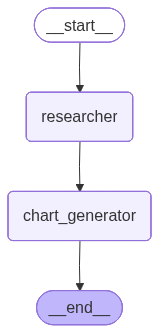

In [26]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Graph image rendering skipped:", e)

In [27]:
result = graph.invoke(
    {
        "messages": [
            (
                "user",
                "2020년 한국의 코로나 19 확진자 수를 조사하여, 이를 차트로 만들어주세요. "
                "누적확진자와 신규확진자가 모두 포함되어야 합니다. "
                "차트 속 글씨는 영어로 작성하세요. "
                "차트를 만들고 나면 끝내세요."
            )
        ]
    },
    config={"recursion_limit": 20},
)

for msg in result["messages"]:
    role = getattr(msg, "type", "unknown")
    name = getattr(msg, "name", None)
    print("=" * 80)
    print("role :", role)
    print("name :", name)
    print("content:")
    print(msg.content)

role : human
name : None
content:
2020년 한국의 코로나 19 확진자 수를 조사하여, 이를 차트로 만들어주세요. 누적확진자와 신규확진자가 모두 포함되어야 합니다. 차트 속 글씨는 영어로 작성하세요. 차트를 만들고 나면 끝내세요.
role : human
name : researcher
content:
Research result from researcher agent.

Use this JSON as the authoritative dataset for chart creation:

{
  "chart_title": "South Korea COVID-19 Confirmed Cases in 2020",
  "x_label": "Date",
  "y_label_left": "Daily New Confirmed Cases",
  "y_label_right": "Cumulative Confirmed Cases",
  "data": [
    {
      "date": "2020-01-20",
      "new_cases": 1.0,
      "cumulative_cases": 1.0
    },
    {
      "date": "2020-01-31",
      "new_cases": 4.0,
      "cumulative_cases": 11.0
    },
    {
      "date": "2020-02-07",
      "new_cases": 1.0,
      "cumulative_cases": 24.0
    },
    {
      "date": "2020-02-14",
      "new_cases": 1.0,
      "cumulative_cases": 28.0
    },
    {
      "date": "2020-02-21",
      "new_cases": 100.0,
      "cumulative_cases": 204.0
    },
    {
      "date": "2020-02-28",


chart exists: True /content/agent_outputs/chart.png
csv exists  : True /content/agent_outputs/chart_data.csv


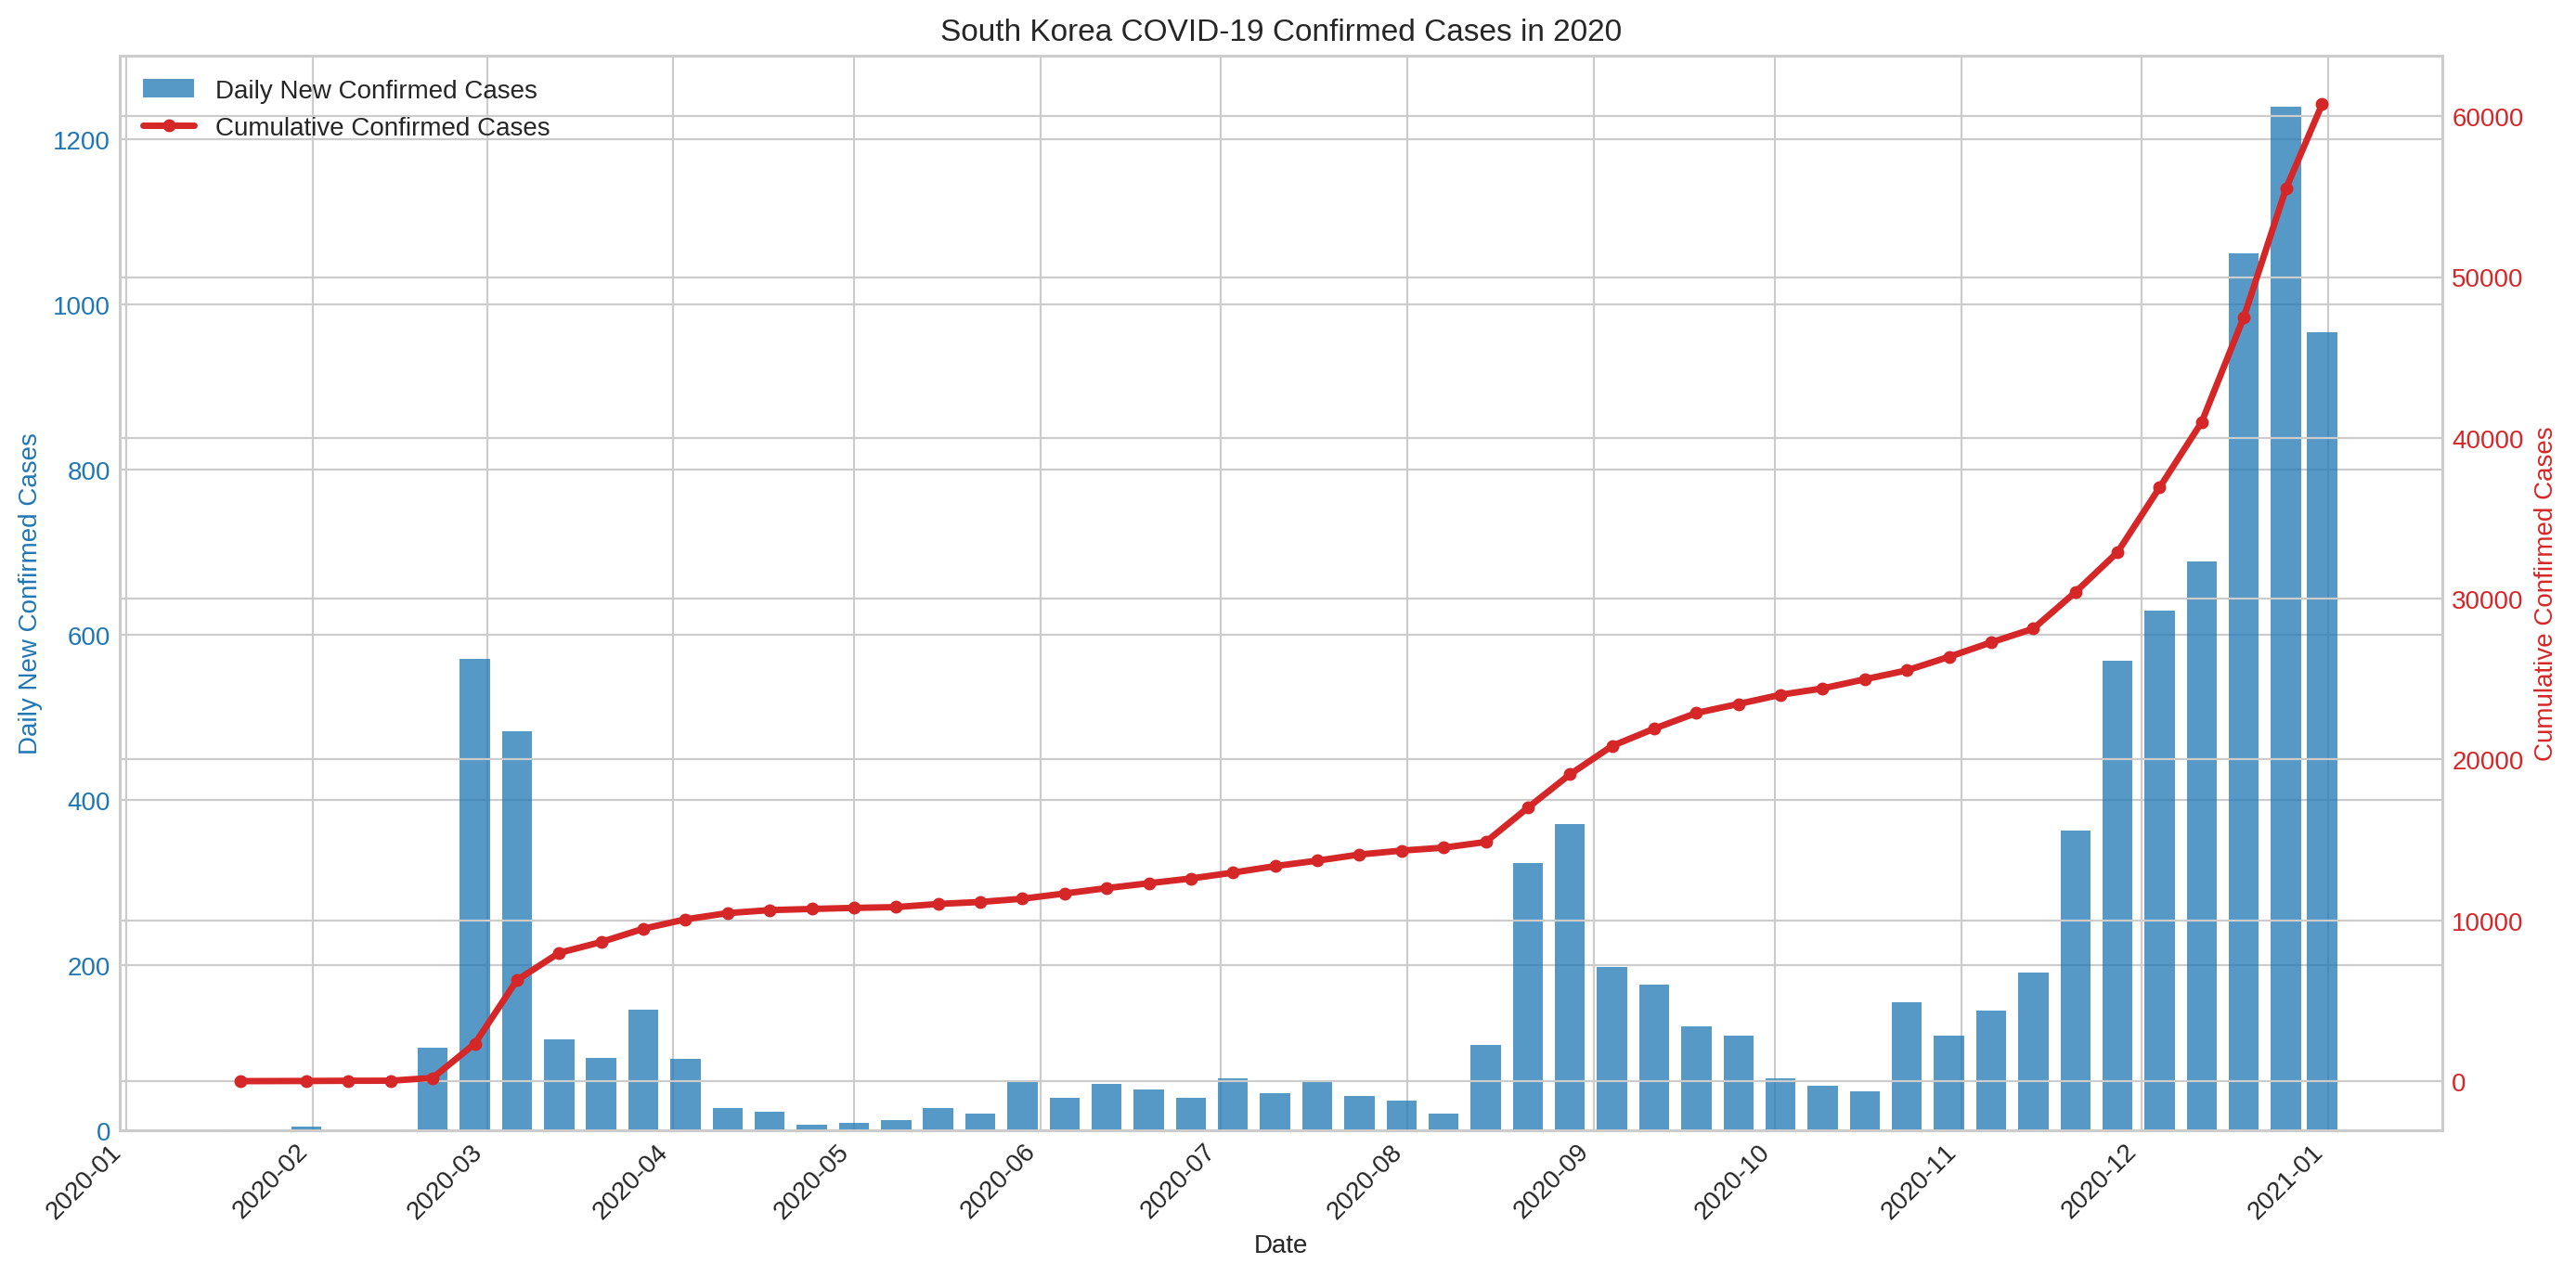

         date  new_cases  cumulative_cases
0  2020-01-20        1.0               1.0
1  2020-01-31        4.0              11.0
2  2020-02-07        1.0              24.0
3  2020-02-14        1.0              28.0
4  2020-02-21      100.0             204.0
rows: 50


In [28]:
from IPython.display import display, Image as IPImage
from pathlib import Path

chart_path = OUTPUT_DIR / "chart.png"
csv_path = OUTPUT_DIR / "chart_data.csv"

print("chart exists:", chart_path.exists(), chart_path)
print("csv exists  :", csv_path.exists(), csv_path)

if chart_path.exists():
    display(IPImage(filename=str(chart_path)))

if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(df.head())
    print("rows:", len(df))